## View human one-shot behavior from Experiment 2

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from hobj.benchmarks import MutatorOneshotBenchmark
benchmark2 = MutatorOneshotBenchmark()
target_statistics = benchmark2.target_statistics
print(target_statistics)

<xarray.GeneralizationStatistics> Size: 583kB
Dimensions:               (transformation: 36, boot_iter: 1000)
Coordinates:
  * transformation        (transformation) <U26 4kB 'backgrounds | 0.1' ... '...
    transformation_type   (transformation) <U18 3kB 'backgrounds' ... 'scale'
    transformation_level  (transformation) float64 288B 0.1 0.2154 ... 0.5 1.5
Dimensions without coordinates: boot_iter
Data variables:
    phat                  (transformation) float64 288B 0.9969 1.0 ... 0.945 1.0
    varhat_phat           (transformation) float64 288B 0.0003446 ... 0.0003748
    boot_phat             (boot_iter, transformation) float64 288kB 1.0 ... 0...
    boot_varhat_phat      (boot_iter, transformation) float64 288kB 0.0003686...


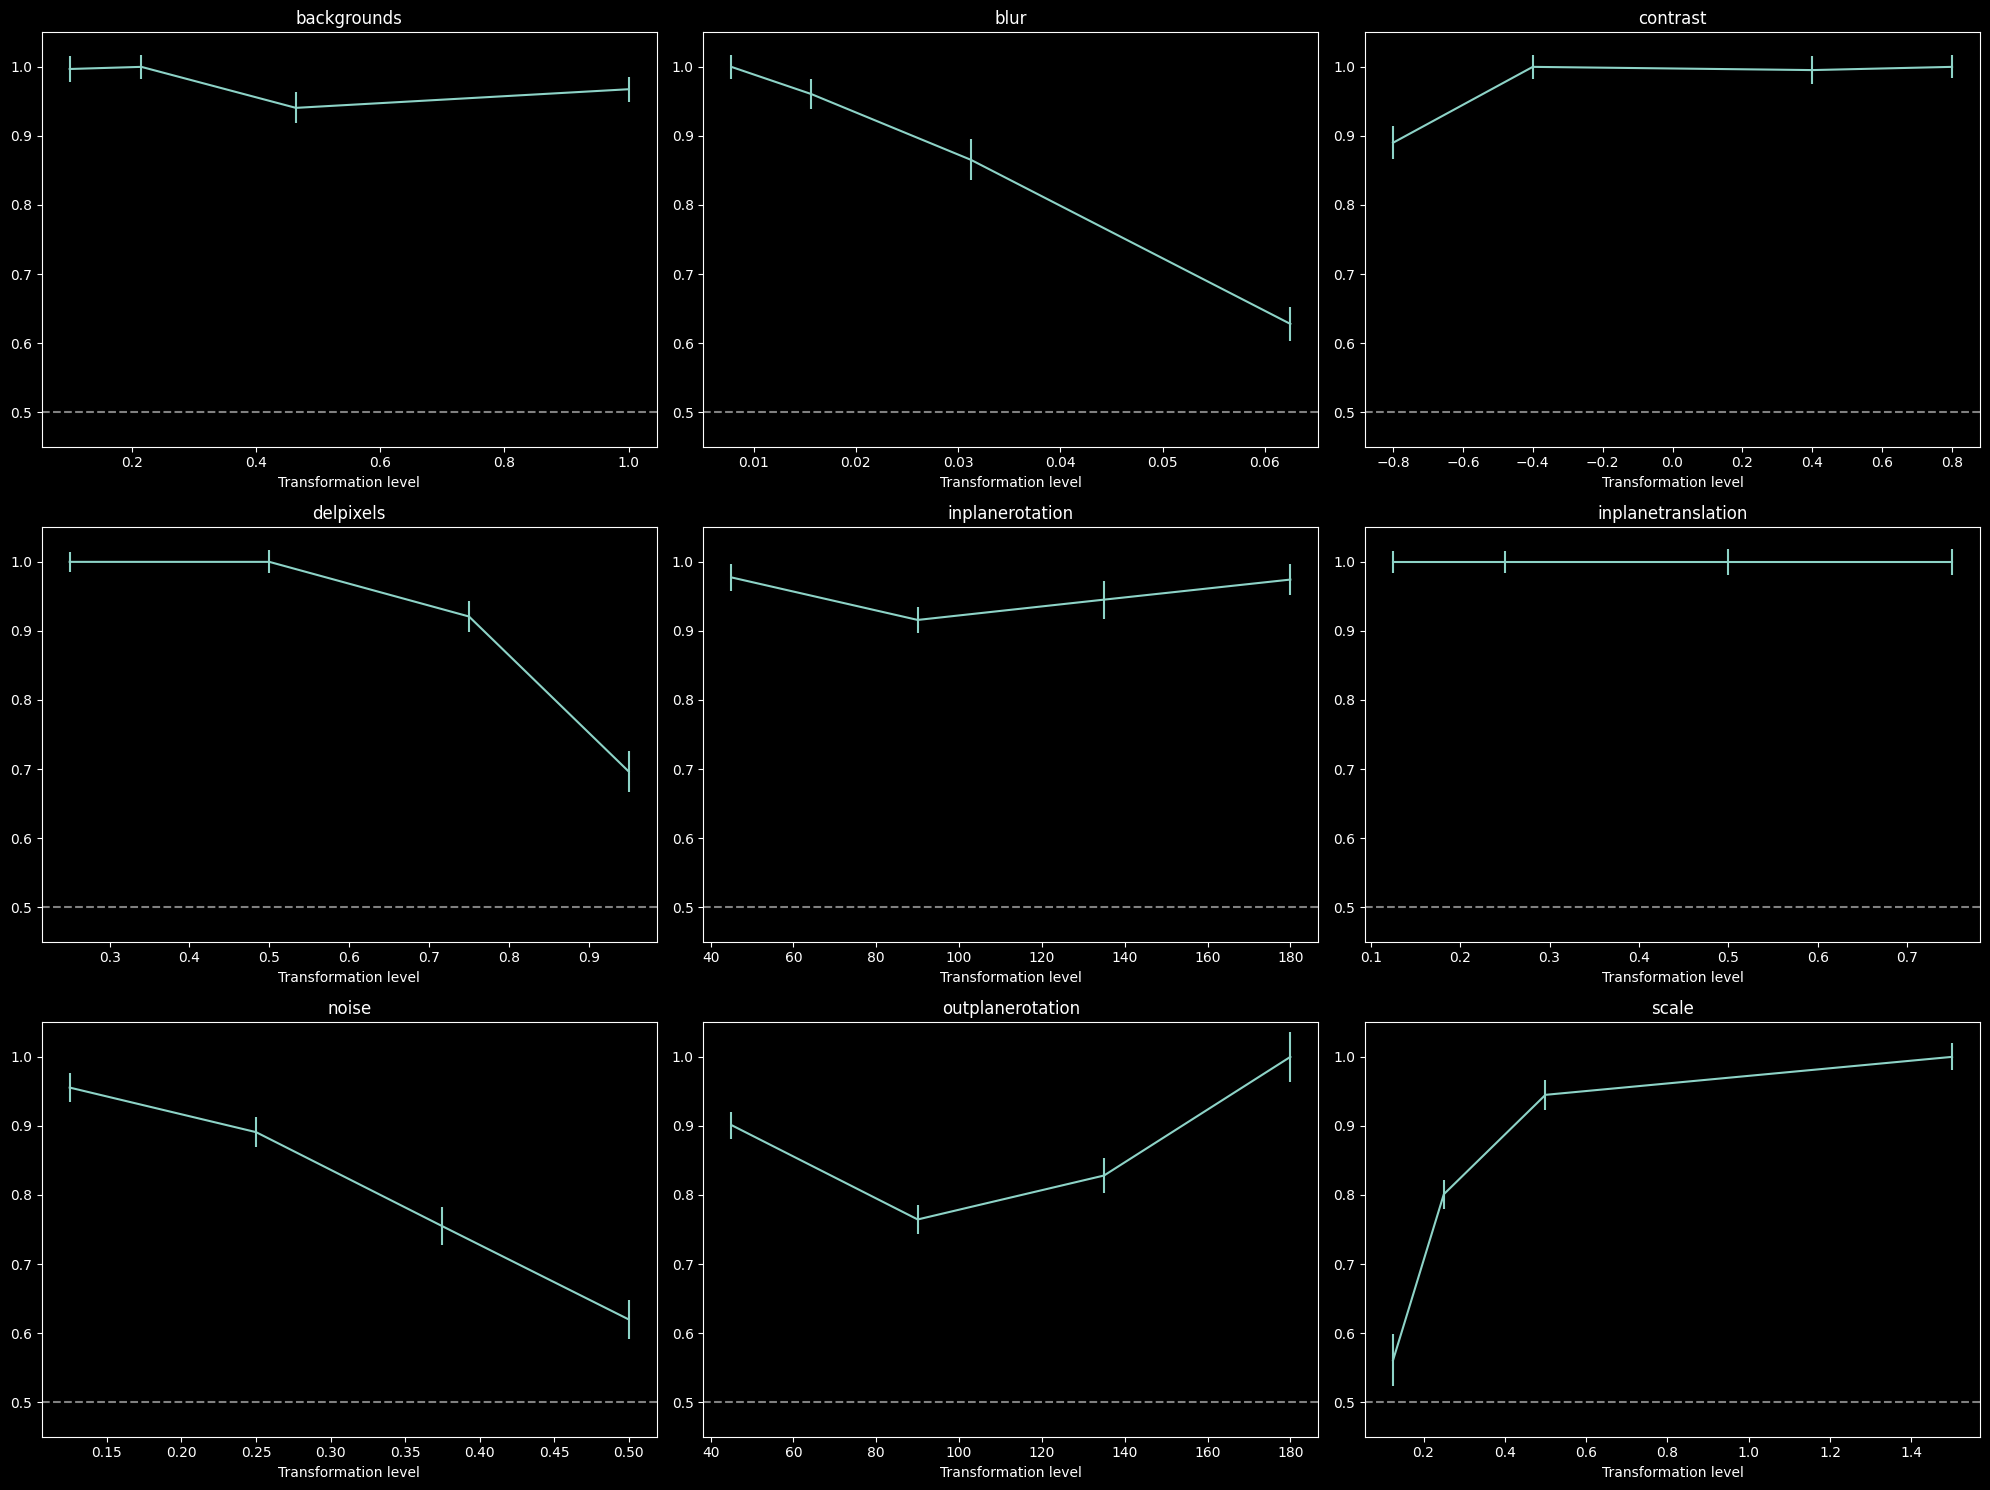

In [3]:
# Plot by transformation
fig, ax = plt.subplots(3, 3, figsize=(20, 15))
c=0
for transformation, ds in target_statistics.groupby('transformation_type'):
    ds = ds.sortby('transformation_level')
    x = ds.transformation_level.values
    y = ds.phat.values
    yerr = np.sqrt(ds.varhat_phat.values)
    
    
    
    # Plot
    i, j = c // 3, c % 3
    c+=1
    
    plt.sca(ax[i, j])
    plt.title(transformation)
    plt.ylim([0.45, 1.05])
    plt.axhline(0.5, color='gray', linestyle='--')

    plt.errorbar(x, y, yerr=yerr, )
    plt.xlabel('Transformation level')

plt.tight_layout()
